<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_2_MLR/17_2_4_5_MLR_Ames_Part5_Revised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLR Predicting Housing Prices in Ames Iowa: Part 5
## Tree-Based Methods

**Author:** Brad Sheese

**Data Source:** http://jse.amstat.org/v19n3/decock/AmesHousing.txt

---

If you've not seen this material before I highly recommend you watch this StatQuest video. It is short and very good at communicating the specifics of how trees are generated. https://www.youtube.com/watch?v=g9c66TUylZ4

Pay particularly close attention to the description of how residuals are used to determine how splits are made (around the 7 minute mark).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Download the cleaning module from GitHub
import urllib.request
module_url = "https://raw.githubusercontent.com/bsheese/cs377/main/17_regression_crossval/ames_cleaning.py"
urllib.request.urlretrieve(module_url, "ames_cleaning.py")
from ames_cleaning import load_and_clean_ames

# Load and clean the Ames dataset (no one-hot encoding - trees handle categoricals)
df = load_and_clean_ames(one_hot_encode=False)
print(f"DataFrame shape: {df.shape}")


DataFrame shape: (2925, 38)


In [ ]:
from sklearn.model_selection import train_test_split

# For Decision Trees and Random Forests, we need numeric data.
# Unlike linear models, trees do not require one-hot encoding. They can work
# with categorical features as long as the categories are represented as numbers.
# We use .cat.codes to convert each category to an integer (e.g., 'PConc' → 0, 'CBlock' → 1).
# This preserves the categorical nature without exploding the feature count.
# Note: Later models (HistGradientBoosting and XGBoost) will accept category dtypes natively.
X = df.drop(columns=['SalePrice']).copy()
y = df['SalePrice'].map(np.log)

# Convert category columns to numeric codes for models that do not support them natively
for col in X.select_dtypes(include=['category']).columns:
    X[col] = X[col].cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Setup complete. Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Setup complete. Train shape: (2340, 37), Test shape: (585, 37)


## Why Trees?

In Parts 1-4, we built and refined linear regression models. We learned to select features, handle multicollinearity, apply regularization, and tune hyperparameters. But linear models come with an inherent constraint: they assume the relationship between each feature and the target is fundamentally a straight line. To try to capture non-linear patterns, we had to manually engineer polynomial features in Part 2.

Tree-based models take a completely different approach. Instead of fitting a single equation with coefficients, a tree partitions the data into regions and predicts the average target value within each region. This means the model can naturally capture patterns that required manual effort in linear regression. For example:

*   **Diminishing Returns:** Increasing `Garage Area` from 0 to 400 sq ft adds a lot of value. Increasing it from 1000 to 1400 adds much less. A tree captures this by splitting at different thresholds.
*   **Threshold Effects:** Houses built after a certain year might command a specific premium due to building codes or styles. A tree finds these breakpoints automatically.
*   **Feature Interactions:** `Overall Qual` might matter more in certain neighborhoods than others. A tree captures this by splitting on one feature, then another, within each branch.

In this notebook, we will explore three tree-based methods, each building on the last:

1.  **Decision Trees** — A single tree. Highly interpretable, but prone to overfitting.
2.  **Random Forests** — Hundreds of trees trained in parallel and averaged together. Stable and robust.
3.  **Gradient Boosting** — Trees built sequentially, each one correcting the errors of the last. Often the most accurate.

We will focus on regression trees (predicting a continuous value). Classification trees, which predict categories, will be covered in the next modeule.

## How a Regression Tree Works

Think of a Decision Tree like a game of "20 Questions." The model tries to predict a house's price by asking a series of binary yes/no questions:

1.  "Is the house larger than 2,000 sq ft?" (Yes/No)
2.  "Is the Overall Quality greater than 7?" (Yes/No)
3.  "Does it have a finished basement?" (Yes/No)

Each question splits the data into two groups. The model keeps splitting until it reaches a stopping point. At that point, it predicts the **average price** of the houses in that final group.

Here is how the pieces map to machine learning terminology:

*   **Node (Decision Node):** A point where the tree asks a question. The root node is the very first split.
*   **Branch:** The "yes" or "no" path that leads from one node to the next.
*   **Leaf (Terminal Node):** An endpoint where the tree stops splitting. The prediction is the average target value of all training samples that land in that leaf.

You can picture each house flowing down through a branching path of decision nodes until it settles into a leaf, where it receives its predicted price.

### How Does the Tree Choose Its Questions?

The tree does not ask questions at random. At each node, it tries every possible split point on every feature and picks the one that reduces prediction error the most (technically, the split that minimizes the variance of the target values in the resulting child nodes). It repeats this process recursively, meaning that it does this over and over again until its done.

### The Overfitting Problem

If we let the tree keep splitting without any limits, it will eventually create a separate leaf for nearly every individual house in the training set. The result? A model that achieves a perfect R² of 1.0 on training data by memorizing it, but performs poorly on any new data. This is classic overfitting. The model has learned too much noise, which obscures the pattern.

The key hyperparameter for controlling this is `max_depth`, which limits how many questions the tree is allowed to ask along any path. Let's see what happens as we vary it.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# 1. Define a list of max_depth values to experiment with
# We test a range from shallow (underfitting) to unconstrained (overfitting)
# to find the depth that best balances bias and variance.
max_depth_values = [3, 5, 7, 9, 11, None]

# 2. Initialize empty lists for results
depths = []
train_r2s = []
test_r2s = []

print("--- Decision Tree Regressor Performance by Max Depth ---")

# 3. Loop through each max_depth value
for depth in max_depth_values:
    # 4a. Instantiate a DecisionTreeRegressor
    dt_regressor = DecisionTreeRegressor(max_depth=depth, random_state=42)

    # 4b. Fit the regressor to the training data
    dt_regressor.fit(X_train, y_train)

    # 4c. Calculate the R² score on the training data
    train_r2 = dt_regressor.score(X_train, y_train)
    train_r2s.append(train_r2)

    # 4d. Calculate the R² score on the testing data
    test_r2 = dt_regressor.score(X_test, y_test)
    test_r2s.append(test_r2)

    # 4e. Append the current max_depth value
    depths.append(str(depth) if depth is not None else 'None (Unconstrained)')

    print(f"Max Depth: {str(depth) if depth is not None else 'None (Unconstrained)':<20} | Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")

# 5. Create a Pandas DataFrame from the collected results
dt_results_df = pd.DataFrame({
    'Max Depth': depths,
    'Train R2': train_r2s,
    'Test R2': test_r2s
})

# print("\nDecision Tree Results DataFrame:")
# print(dt_results_df.to_string(index=False, float_format="%.4f"))

--- Decision Tree Regressor Performance by Max Depth ---
Max Depth: 3                    | Train R²: 0.7057 | Test R²: 0.7484
Max Depth: 5                    | Train R²: 0.8268 | Test R²: 0.8178
Max Depth: 7                    | Train R²: 0.9036 | Test R²: 0.8319
Max Depth: 9                    | Train R²: 0.9501 | Test R²: 0.8251
Max Depth: 11                   | Train R²: 0.9785 | Test R²: 0.8115


Max Depth: None (Unconstrained) | Train R²: 1.0000 | Test R²: 0.7986

Decision Tree Results DataFrame:
           Max Depth  Train R2  Test R2
                   3    0.7057   0.7484
                   5    0.8268   0.8178
                   7    0.9036   0.8319
                   9    0.9501   0.8251
                  11    0.9785   0.8115
None (Unconstrained)    1.0000   0.7986


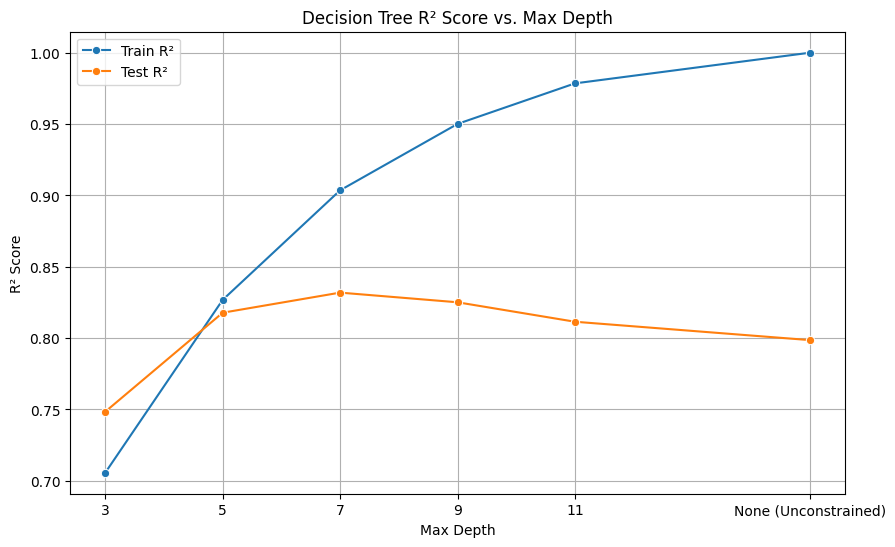

In [ ]:
# Prepare data for plotting
plot_df = dt_results_df.copy()
# Convert 'Max Depth' column to numeric for plotting, treating 'None (Unconstrained)' as a large number or specific category
# For visualization, it's often better to represent 'None' distinctly or order it last.
# For a numeric plot, we can assign an arbitrary large number or handle it as a categorical value.
# Let's convert it to a numeric type, assigning a distinct value for 'None' for proper ordering in the plot
plot_df['Max Depth Num'] = plot_df['Max Depth'].replace({'None (Unconstrained)': 15}).astype(float) # Assigning 15 as an example, larger than 11

plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df, x='Max Depth Num', y='Train R2', marker='o', label='Train R²')
sns.lineplot(data=plot_df, x='Max Depth Num', y='Test R2', marker='o', label='Test R²')

# Customize x-axis ticks to show original labels
x_tick_labels = plot_df['Max Depth'].tolist()
x_tick_positions = plot_df['Max Depth Num'].tolist()
plt.xticks(ticks=x_tick_positions, labels=x_tick_labels)

plt.title('Decision Tree R² Score vs. Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('R² Score')
plt.grid(True)
plt.legend()
plt.show()

## Interpreting the Results

The table and plot above reveal the classic bias-variance tradeoff we saw in Part 4, now expressed through tree depth:

*   **Depth 3 (High Bias / Underfitting):** Both training and test scores are moderate (~0.71-0.75). The tree is too shallow to capture the complexity of the data. It is asking too few questions.
*   **Depth 5-7 (Sweet Spot):** The test R² peaks at depth 7 (0.8319). The tree is complex enough to capture meaningful patterns but not so complex that it memorizes noise. This is the best generalization we see.
*   **Depth 9-11 (Increasing Overfitting):** The training score continues climbing (0.95 → 0.98), but the test score starts to drop. The gap between the two lines widens. The tree is now fitting noise specific to the training set.
*   **Depth None (Unconstrained / Perfect Memorization):** The training R² hits 1.0000 — the tree has perfectly memorized every training house. But the test R² falls to 0.7986, worse than even the shallow depth-3 model. This is the most extreme form of overfitting possible.

The plot makes this divergence visually clear: the training score (blue) climbs steadily toward 1.0, while the test score (orange) peaks around depth 7 and then declines. The gap between the two lines is the overfitting penalty.

This is the same pattern we observed with polynomial features in Part 2: as model complexity increases, training performance always improves, but test performance eventually deteriorates. The difference is that with trees, complexity is controlled by a single intuitive parameter (depth) rather than by manually engineering polynomial terms.

So how do we prevent a single tree from overfitting? One approach is to limit its depth. But a more powerful approach is to build many trees and combine their predictions. This is the idea behind Random Forests.

## Visualizing a Single Tree
Before we get into that, check out the nodes in this single tree of depth 5. In the first few levels you can see the specific values the tree identified for each decision.

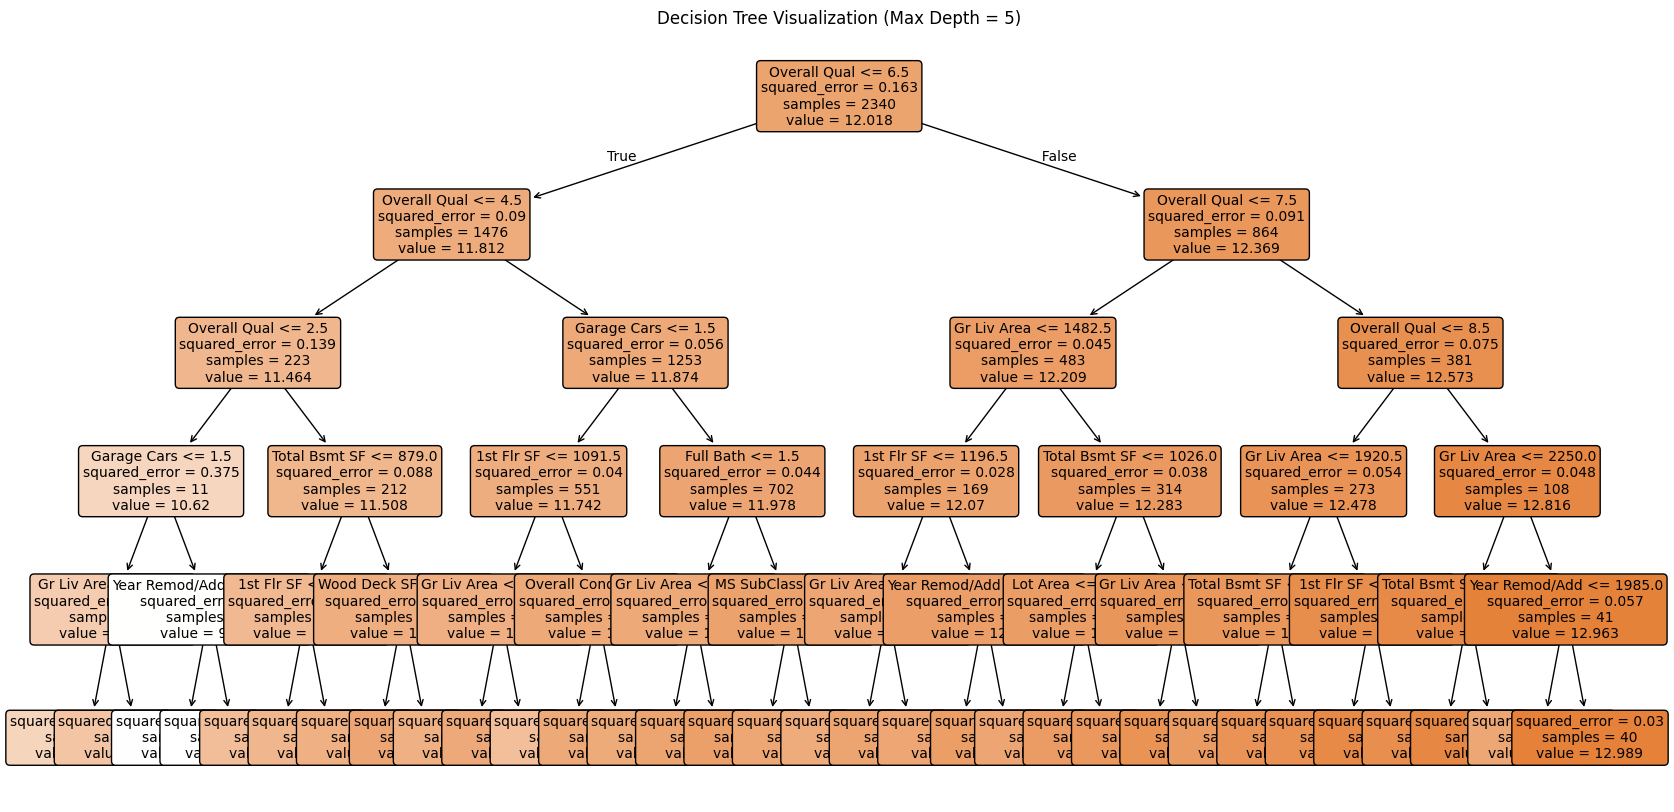

In [ ]:
# visualize our depth 5 tree

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# Instantiate a DecisionTreeRegressor with max_depth=5 and random_state=42
dt_depth5 = DecisionTreeRegressor(max_depth=5, random_state=42)

# Fit the model using X_train and y_train
dt_depth5.fit(X_train, y_train)

# Use plt.figure to set a large figure size to ensure the tree is legible
plt.figure(figsize=(20, 10))

# Call plot_tree passing the fitted model
plot_tree(dt_depth5,
          feature_names=X_train.columns,
          filled=True,
          rounded=True,
          fontsize=10)

# Display the plot
plt.title('Decision Tree Visualization (Max Depth = 5)')
plt.show()

### Reading the Tree

Take a moment to examine the tree visualization above. Here is what to look for:

*   **The Root Node (top box):** This is the tree's first and most important split. Which feature did it choose? This is the single strongest predictor of house price according to the tree.
*   **Feature Repetition:** Notice that the same features appear multiple times at different depths. For example, a feature might be used to split at depth 1, and then appear again at depth 3 within a specific branch. This is how trees capture interactions — the meaning of a feature can change depending on the path you took to reach it.
*   **The Leaves (bottom boxes):** Each leaf shows a `value` (the predicted log-price for houses in that group) and `samples` (how many training houses landed there). Leaves with very few samples are a warning sign — the model is making predictions based on a tiny number of examples.

Even at just depth 5, this tree is already becoming difficult to read. At depths of 10 or more, a visualization would be completely illegible. This is one reason why single trees, while interpretable at shallow depths, become "black boxes" as they grow deeper. It is also a preview of why we need ensemble methods: if one tree is hard to read at depth 5, imagine trying to interpret a forest of 200 trees.

## Random Forests: Ensemble Learning via Bagging and Parallelization

A single decision tree has a fundamental weakness: it overfits. Left unchecked, it memorizes the training data. Even when we limit its depth, a single tree is highly sensitive to the specific houses it was trained on, change a few data points and the entire tree structure can shift.

So what if, instead of building one carefully pruned tree, we built many imperfect trees and averaged their predictions?

Think of it like the "wisdom of the crowd." If you ask one person to guess the price of a house, they might be way off. But if you ask 100 people and average their guesses, the average is often surprisingly accurate. Individual errors cancel out. This is the core idea behind a Random Forest.

However, if every tree sees the same data and considers the same features, they will all make the *same* mistakes. Averaging identical predictions doesn't help. To make the crowd genuinely diverse, the Random Forest introduces two sources of randomness:

**1. Bootstrap Aggregating (Bagging) — Randomizing the Data**

Each tree is trained on a random sample of the training data, drawn *with replacement*. This means some houses appear multiple times in a tree's training set, while others don't appear at all. Tree #47 might never see the most expensive mansion in the dataset, so it develops a different perspective on what drives prices. Tree #83 might get an unusual concentration of older homes, making it better at valuing them.

**2. Feature Randomness — Randomizing the Features**

Even with different data, a dominant feature like `Overall Qual` would still be chosen as the first split by nearly every tree. To prevent this, at every single node each tree is only allowed to consider a random subset of the available features. If `Overall Qual` isn't in the subset, the tree is forced to find the next-best split. This decorrelates the trees and ensures the forest explores many different patterns in the data.

Because every tree is built independently (e.g,  different data, different feature subsets) they do not need to communicate or learn sequentially. This allows them to be trained in parallel across multiple CPU cores.

From a machine learning perspective, the Random Forest's primary job is variance reduction. Individual trees overfit and generate noisy predictions. But when you average hundreds of diverse, uncorrelated opinions, the noise cancels out. The result is a model that is far more stable and accurate than any single tree could be.

### Tuning the Random Forest

We will use GridSearchCV to find the best combination of three key hyperparameters:

*   `n_estimators`: How many trees to build. More trees = more stable, but slower.
*   `max_depth`: How deep each tree can grow. Unlike a single tree, Random Forests can often benefit from deeper (or even unlimited depth) trees because the averaging process controls overfitting.
*   `max_features`: How many features each tree considers at each split. `'sqrt'` means the square root of the total number of features — the default and most common choice.

Note: Unlike linear models, tree-based models do **not** require feature scaling. We pass the data directly to the model.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'max_features': [1.0, 'sqrt']
}

print("--- Tuning Random Forest ---")

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV R²:      {rf_grid.best_score_:.4f}")

best_rf = rf_grid.best_estimator_

--- Tuning Random Forest ---
Fitting 5 folds for each of 12 candidates, totalling 60 fits



Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV R²:      0.8772


### Interpreting the Random Forest Results

Our tuned Random Forest achieved a CV R² of **0.8771**, an improvement over the single decision tree's best test R² of **0.8319** at depth 7. This is the payoff of ensembling; by averaging many diverse trees, we reduced the variance that limited any single tree.

Notice the best parameters:

*   **`max_depth=None`**: The forest chose unlimited tree depth. For a single tree, this would be catastrophic (R² = 0.7986 on test). But in a forest, the averaging process controls overfitting, so deeper trees can capture more nuance without harming generalization.
*   **`max_features='sqrt'`**: Each tree considers only about 6 features (√37 ≈ 6) at each split. This forces diversity. If it had chosen `1.0` (all features), the trees would be more correlated and the ensemble less effective.
*   **`n_estimators=100`**: 100 trees was sufficient. Adding more (200) didn't improve the score, suggesting the forest had already stabilized.



## Gradient Boosting: Ensemble Learning via Sequential Refinement

Random Forests build trees in parallel and hope the crowd is wise. But there is another approach: what if each tree could actually learn from the mistakes of the trees that came before it?

This is the idea behind Gradient Boosting. Instead of independent trees voting in parallel, boosting builds trees sequentially, where each new tree is trained specifically to correct the errors of the ensemble so far.

### Example of Gradient Boosting

1.  **Initial Prediction:** The model starts with the simplest possible guess, the average log-price of all training houses. Let's say that's ~12.0. Every house gets this same prediction.
2.  **Calculate Residuals:** The model looks at its errors. House #42 (a small fixer-upper) was predicted at 12.0 but actually sold for 11.2. Its residual is -0.8. House #101 (a renovated colonial) was predicted at 12.0 but sold for 12.9. Its residual is +0.9.
3.  **Train Tree #2 on the Residuals:** The next tree is not trained to predict house prices. It is trained to predict the residuals. It learns patterns like: "small houses in this neighborhood tend to be overpriced by the average" and "renovated homes in this area are underpriced."
4.  **Update the Predictions:** Tree #2's predictions are added to the running total, nudging each house closer to its true price. House #42's new prediction: 12.0 + (-0.7) = 11.3. Closer.
5.  **Repeat:** The model recalculates the new, smaller residuals and trains Tree #3 on those. Each tree makes progressively smaller corrections. After 200 trees, the residuals are tiny.

You can think of this like a specialized assembly line. The first worker cuts out the rough shape. Every subsequent worker focuses only on sanding down the exact rough edges left by the person before them.

### Bias vs. Variance

This is the key difference between the two ensemble approaches:

| | Random Forest | Gradient Boosting |
|---|---|---|
| **Strategy** | Build many deep trees in parallel, then average | Build many shallow trees sequentially, each correcting errors |
| **Target** | Reduces **variance** (averages out noise) | Reduces **bias** (chips away at underfitting) |
| **Analogy** | Wisdom of the crowd | Specialized assembly line |

---

*Note on Implementation:* We use `HistGradientBoostingRegressor`, Scikit-Learn's modern boosting implementation. It speeds up the algorithm by grouping continuous data into discrete "bins" (histograms) before making splits, making it fast even on large datasets.

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# HistGradientBoostingRegressor handles categorical features natively
# so we can use our original X (with category dtypes) directly.
# We re-split to get clean train/test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

hgb_model = HistGradientBoostingRegressor(
    max_iter=200,        # Number of sequential trees to build
    learning_rate=0.1,   # How much each tree contributes (smaller = more trees needed, but more stable)
    random_state=42
)

hgb_model.fit(X_train, y_train)

y_pred = hgb_model.predict(X_test)

# Note: RMSE is in log-price units since our target is log-transformed.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"HistGradientBoosting Performance:")
print(f"--- Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"--- R-squared (R²): {r2:.4f}")

HistGradientBoosting Performance:
--- Root Mean Squared Error (RMSE): 0.10
--- R-squared (R²): 0.9392


### How Robust Are Tree Models to Messy Data?

In Parts 1 and 2, we spent two full notebooks cleaning the Ames dataset: dropping uninformative features, handling missing values, encoding categories, and removing outliers. For linear regression, this cleaning was essential.

Tree-based models are more forgiving. They don't require one-hot encoding, they handle non-linear relationships automatically, and some implementations (like `HistGradientBoostingRegressor`) can even handle missing values natively.

Let's test that claim. Below, we load the raw Ames data, with only the extreme outlier removal, and run HGB on it with almost no preprocessing. The only steps are: log-transform the target and convert object columns to category dtype.

In [ ]:
# Data source
url = 'https://raw.githubusercontent.com/bsheese/CSDS125ExampleData/master/data_housing_ames.txt'

# Loading the dataframe
df_raw = pd.read_csv(url, sep='\t')

# Initial cleaning: remove extreme outliers per the author's recommendation
df = df_raw.loc[df_raw['Gr Liv Area'] < 4000, :].copy()

# Define features and target
X = df.drop(columns=['SalePrice'])
y = df['SalePrice'].map(np.log)

# Convert object columns to 'category' dtype for native support
obj_cols = X.select_dtypes(include=['object', 'string']).columns
X[obj_cols] = X[obj_cols].astype('category')

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train with categorical support
hgb_model = HistGradientBoostingRegressor(
    max_iter=200,
    learning_rate=0.1,
    random_state=42,
    categorical_features='from_dtype'
)

hgb_model.fit(X_train, y_train)

y_pred = hgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"HistGradientBoosting Performance (Raw Data with Categories):")
print(f"Root Mean Squared Error (RMSE): {rmse:,.4f}")
print(f"R-squared (R²): {r2:.4f}")

HistGradientBoosting Performance (Raw Data with Categories):
Root Mean Squared Error (RMSE): 0.0976
R-squared (R²): 0.9449


The raw-data model achieved an R² of **0.9449**, without any cleaning. This demonstrates a key advantage of tree-based methods: they are remarkably robust to messy, unprocessed data. You still benefit from thoughtful feature engineering, but you don't need it to get strong results.

## XGBoost: eXtreme Gradient Boosting

If standard Gradient Boosting is a specialized assembly line, XGBoost is that same assembly line but with better tools, tighter quality control, and a faster conveyor belt.

XGBoost (eXtreme Gradient Boosting) does not change the core philosophy of boosting. Trees are still built one by one to correct the residuals of the previous trees. But it improves the framework in three important ways:

**1. Built-in Regularization**

Remember Ridge and Lasso from Part 3? They penalized large coefficients to prevent overfitting. XGBoost applies the same idea to trees. When evaluating a potential split, it doesn't just ask "does this reduce error?" It also asks "does this make the tree too complex?" It applies L1 (`reg_alpha`) and L2 (`reg_lambda`) penalties on the leaf weights, which shrinks extreme predictions and prunes weak splits. This means XGBoost can safely use deeper trees without overfitting as badly as standard boosting.

**2. Speed**

Boosting is inherently sequential — Tree 2 can't start until Tree 1 finishes. This makes it hard to parallelize. XGBoost gets around this by parallelizing the *internal* work of building each tree. Finding the best split requires sorting thousands of values, which is expensive. XGBoost uses an approximate algorithm and parallelized feature sorting to evaluate splits across multiple CPU threads simultaneously. Consrquntly it trains much faster than standard boosting.

**3. Native Missing Data Handling**

Like `HistGradientBoostingRegressor`, XGBoost handles missing values without imputation. At each split, it tests sending missing values left or right and learns which direction reduces error more. If a house is missing its `Garage Quality` score, XGBoost figures out whether that absence itself is informative.

In [ ]:
from xgboost import XGBRegressor

# Use the same cleaned raw data from the HGB section above
X = df.drop(columns=['SalePrice'])
y = df['SalePrice'].map(np.log)

# Convert object columns to 'category' dtype
obj_cols = X.select_dtypes(include=['object', 'string']).columns
X[obj_cols] = X[obj_cols].astype('category')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    reg_alpha=0.1,     # L1 regularization (like Lasso)
    reg_lambda=1.0,    # L2 regularization (like Ridge)
    enable_categorical=True,  # Native pandas 'category' dtype support
    tree_method='hist',       # Histogram binning for speed (same idea as HGB)
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost Performance (with Native Categorical Support):")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")

XGBoost Performance (with Native Categorical Support):
Root Mean Squared Error (RMSE): 0.10
R-squared (R²): 0.9418


### Comparing the Three Boosting Approaches

How did XGBoost (R² = 0.9418) compare to `HistGradientBoostingRegressor` (R² = 0.9392)? They are very close. On a dataset this size, both are excellent choices. XGBoost tends to shine on larger datasets and in competitive settings (like Kaggle) where every fractional improvement matters and its regularization gives it an edge.

Both models significantly outperformed our Random Forest (R² = 0.8771) and our best single decision tree (R² = 0.8319). The sequential, error-correcting approach of boosting is simply more powerful than parallel averaging for this kind of structured tabular data.

## Feature Importance

Because complex ensembles like Random Forests and XGBoost build hundreds of deeply layered trees, they are frequently criticized as "black boxes." Unlike a simple linear model, you cannot just look at a mathematical equation to understand how the final prediction was made. However, these algorithms actually keep  internal records of their decision-making processes, which we can extract as Feature Importance.

---

To understand how this works, it helps to contrast it directly with traditional statistics:

**Linear Model (Coefficients)**

In a standard linear regression, you are given a coefficient. This is a direct economic multiplier. A coefficient of 50 on "Square Footage" means exactly: for every 1 additional square foot, the house price increases by $50. It is highly interpretable, but it forces a rigid, linear assumption onto the data.

**Tree Model (Impurity / Error Reduction)**

Tree ensembles do not calculate linear multipliers; they calculate usefulness.
Every single time a tree creates a decision node (e.g., "Is Overall Quality > 7?"), it measures exactly how much that specific split reduced the model's overall prediction error (often referred to as decreasing "impurity" or calculating "information gain").

If a split on "Roof Material" barely improves the model's accuracy, it gets a very low score. If a split on "Neighborhood" suddenly makes the subsequent predictions drastically more accurate, it is awarded a massive score for that split.

Across an ensemble of 200 trees, a feature like "Square Footage" might be used to make thousands of different splits. The algorithm simply tallies up the total error reduction attributed to "Square Footage" across every single tree, and divides it by the total error reduction of all features combined.

---
**Relative Predictive Contribution**

Feature Importance is usually expressed as a percentage or a relative score (summing to 1.0). If "Overall Quality" has a score of 0.40, it means that single feature was responsible for 40% of the model's total learning and error reduction.

It is important to note the fundamental limitation here: Feature Importance tells you what the model prioritizes, but it does not tell you how the feature affects the price. It will definitively tell you that "Lot Size" is a massive driver of the model's predictions, but unlike a linear coefficient, the importance score alone won't explicitly tell you whether a larger lot increases or decreases the price. It simply tells you that to the algorithm, the information was heavily relied upon to reach its final answer.

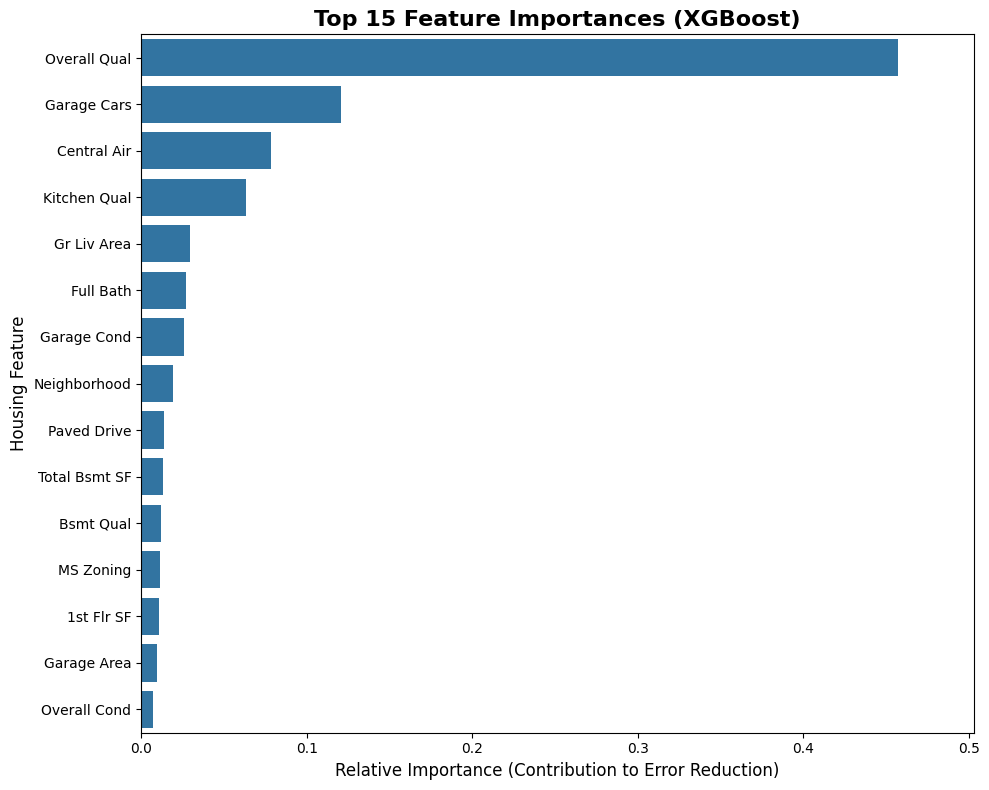

Top 5 Drivers of House Price (According to XGBoost):
- Overall Qual: 45.76%
- Garage Cars: 12.07%
- Central Air: 7.86%
- Kitchen Qual: 6.33%
- Gr Liv Area: 2.98%


In [ ]:
# 1. Extract the importance scores
# XGBoost calculates these automatically during training based on how much
# each feature contributed to reducing the model's overall error.
importances = xgb_model.feature_importances_

# 2. Map the scores to their corresponding feature names
# We use X_train.columns to ensure the names line up exactly with the data the model saw.
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

# 3. Sort the features from most important to least important
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 4. Isolate the Top 15 features (to keep the chart readable)
top_15_features = importance_df.head(15)

# 5. Visualize the results using Seaborn and Matplotlib
plt.figure(figsize=(10, 8))
sns.barplot(
    x='Importance',
    y='Feature',
    data=top_15_features,
)

# Formatting the plot for readability
plt.title('Top 15 Feature Importances (XGBoost)', fontsize=16, weight='bold')
plt.xlabel('Relative Importance (Contribution to Error Reduction)', fontsize=12)
plt.ylabel('Housing Feature', fontsize=12)
plt.xlim(0, top_15_features['Importance'].max() * 1.1) # Add a little padding to the right
plt.tight_layout()
plt.show()

# Print the exact scores for the top 5 features
print("Top 5 Drivers of House Price (According to XGBoost):")
for index, row in top_15_features.head(5).iterrows():
    # Formatting as a percentage to make the relative importance clearer
    print(f"- {row['Feature']}: {row['Importance'] * 100:.2f}%")

### Interpreting the Results

*   **`Overall Qual` (45.76%):** This single feature accounts for nearly half of the model's learning. It dominated our linear models too — it is simply the strongest predictor of price in this dataset. But notice the difference: in linear regression, we could say exactly how much each quality point was worth. Here we only know it was the most important.
*   **`Garage Cars` (12.07%)**
*   **`Central Air` (7.86%)**
*   **`Kitchen Qual` (6.33%)**
*   **`Gr Liv Area` (2.98%):** Living area is important, but its importance is relatively low here. Why? Because `Overall Qual` and `Garage Cars` are correlated with size — bigger houses tend to have higher quality ratings and larger garages. The model is using those correlated features instead, which is a symptom of the multicollinearity issue we discuss next.

### Important Caveat: Correlated Features

Feature importance in tree models can be misleading when features are correlated.

If two features (e.g., `Gr Liv Area` and `Total Bsmt SF`) are highly correlated, the model can only pick ONE of them to make the primary split. That feature gets all the importance credit, while the correlated feature gets none, even though both are equally useful.

We saw this exact issue in Part 2. When we calculated VIF scores for all numeric features, `Gr Liv Area` had a VIF of 118 — extreme multicollinearity. In our XGBoost feature importance plot, `Gr Liv Area` appears at 2.98% while `Total Bsmt SF` doesn't appear in the top 15 at all. This doesn't mean basement size is unimportant; it likely means XGBoost chose `Gr Liv Area` for its splits and `Total Bsmt SF` got no credit.

**What to do:**
- Compare feature importance across multiple models (e.g., Random Forest vs. XGBoost). If different models select different correlated features, that's a warning sign.
- Accept that importance scores are relative, not absolute. They tell you which features the model relied on, not which features are inherently most valuable.

## XGBoost Hyperparameter Tuning: Nested Cross-Validation

Just as we did with linear models in Part 4, we should use nested cross-validation to get an unbiased estimate of XGBoost's performance. This ensures our score isn't inflated by the hyperparameter search.

While algorithms like XGBoost learn the internal rules directly from the data, they cannot choose their own external architecture (hyperparameters). Settings like `n_estimators`, `learning_rate`, and `max_depth` must be tuned.

**1. Inner Loop (Tuning):** Within each training fold, a Grid Search tests every combination of hyperparameters to find the best settings for that specific subset of data.

**2. Outer Loop (Evaluation):** The model, using the best parameters found by the inner loop, is evaluated on an independent holdout fold. This ensures that the performance score isn't just "lucky" due to hyperparameter tuning.

In [ ]:
from sklearn.model_selection import GridSearchCV, cross_val_score, KFold

# 1. Define the Hyperparameter Grid for the INNER loop
param_grid = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'n_estimators': [100, 300]
}

# 2. Initialize the Base Model
base_xgb = XGBRegressor(
    reg_alpha=0.1,
    reg_lambda=1.0,
    enable_categorical=True,
    tree_method='hist',
    random_state=42
)

# 3. Setup Nested Cross-Validation
# Outer loop: evaluates performance
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Inner loop: tunes hyperparameters
inner_cv = KFold(n_splits=3, shuffle=True, random_state=42)

inner_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    cv=inner_cv,
    scoring='r2',
    n_jobs=-1,
    verbose=0
)

# 4. Execute Nested CV (Outer Loop)
print("Starting Nested Cross-Validation... this will take a moment.")
nested_scores = cross_val_score(
    inner_search, X, y, cv=outer_cv, scoring='r2', n_jobs=-1
)

print(f"\nNested CV Complete!")
print(f"Average Nested CV R²: {nested_scores.mean():.4f} ± {nested_scores.std():.4f}")

Starting Nested Cross-Validation... this will take a moment.



Nested CV Complete!
Average Nested CV R²: 0.9177 ± 0.0195


### Interpreting the Nested CV Results

The nested CV R² (**0.9177 ± 0.0195**) is slightly lower than our single train/test split R² (0.9418). This is expected — nested CV gives a more conservative, honest estimate because it accounts for the uncertainty in hyperparameter selection.

**Variance:** The standard deviation of ±0.0195 tells us the model's performance is fairly stable across different data splits. A larger variance would suggest the model is more sensitive to which specific houses end up in the training set.

**Cost:** Nested CV required 5 outer folds × 3 inner folds × 12 hyperparameter combinations = 180 model fits. For a dataset this size, that took just a few seconds. On larger datasets or with larger grids, the computational cost becomes significant.

## Model Comparison Summary

Let's bring everything together. Here is how every model we built in this notebook performed:

| Model | Approach | Best R² | Notes |
|---|---|---|---|
| Decision Tree (depth 7) | Single tree | 0.8319 | Interpretable but overfits easily |
| Random Forest (tuned) | Parallel ensemble | 0.8771 | Stable, robust, hard to mess up |
| HistGradientBoosting | Sequential ensemble | 0.9392 | More powerful, needs careful tuning |
| XGBoost (tuned) | Sequential + regularization | 0.9418 | Best single-split score |
| XGBoost (Nested CV) | Unbiased estimate | 0.9177 ± 0.0195 | Most honest performance estimate |

A few takeaways:

*   Steps up the complexity ladder tend to buy us more accuracy, but at the cost of interpretability and computational efficiency.
*   The optimistic bias is definitely an issues. Notice the gap between XGBoost's single-split score (0.9418) and its nested CV estimate (0.9177). That ~2.4-point difference is the inflation from hyperparameter tuning, exactly what nested CV is designed to catch.


### Final Thought

In this notebook, we moved from a single interpretable but overfitting decision tree (R² ≈ 0.83) to ensemble methods that approach R² ≈ 0.94. All with minimal data cleaning.

Think of OLS regression as one end of the spectrum: very interpretable, but very sensitive to data quality and feature engineering. XGBoost sits at the other end: not very interpretable, but remarkably robust to messy data and capable of capturing complex patterns automatically.

In the next section, we will shift from regression to classification where we predict categories instead of continuous values. Many of the concepts we've learned here (cross-validation, hyperparameter tuning, feature importance) will carry over directly, but the evaluation metrics and model choices will look different.